# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [14]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

In [15]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df.sort_values(by="fam", ascending=False, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref

SILVER_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/SILVER/0_long_run100/"
DATA_PATH = "100_epochs_lr_test_exact.csv"
df, df_ref = get_data(SILVER_PATH + DATA_PATH)

display(df)
display(df_ref)

,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
8,tmRNA,0.384994,0.432668,0.376793,0.383838,0.394090,0.380458,0.341608,0.396885,0.388312
7,telomerase,0.194782,0.170901,0.161511,0.245672,0.167757,0.199648,0.184959,0.184918,0.162217
6,tRNA,0.461996,0.437179,0.492159,0.486111,0.469732,0.453994,0.600253,0.547844,0.638963
5,srp,0.255179,0.211775,0.196430,0.230633,0.209442,0.220521,0.236532,0.209565,0.251920
4,grp1,0.366439,0.408607,0.418871,0.390106,0.406875,0.402716,0.403881,0.424401,0.424699
3,RNaseP,0.406971,0.399132,0.414778,0.414269,0.401087,0.405919,0.451666,0.417858,0.395321
2,5s,0.403715,0.454829,0.465682,0.396471,0.466248,0.428146,0.482878,0.485681,0.466020
1,23s,0.375745,0.458908,0.383317,0.353065,0.417675,0.320480,0.514262,0.361672,0.418123
0,16s,0.402044,0.370454,0.416602,0.404762,0.369656,0.431377,0.404384,0.395598,0.351490


,fam,famfold
8,tmRNA,0.399006
7,telomerase,0.139799
6,tRNA,0.472558
5,srp,0.221373
4,grp1,0.448988
3,RNaseP,0.415738
2,5s,0.430768
1,23s,0.427365
0,16s,0.390484


In [16]:
df_ref.set_index("fam")["famfold"].to_dict()
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [17]:
s = dfn.groupby("modelo")["f1"].mean().sort_values(ascending=False).reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s.to_csv(SILVER_PATH + "/100_epochs_test_rel_f1_exact.csv")
s

,modelo,rel_f1
0,samples_100,1.095971
1,samples_400,1.053425
2,rnadist_100,1.048692
3,samples_200,1.040067
4,hc_200,1.015233
5,hc_100,1.014402
6,rnadist_400,1.006705
7,rnadist_200,1.000568
8,hc_400,1.000435


In [18]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

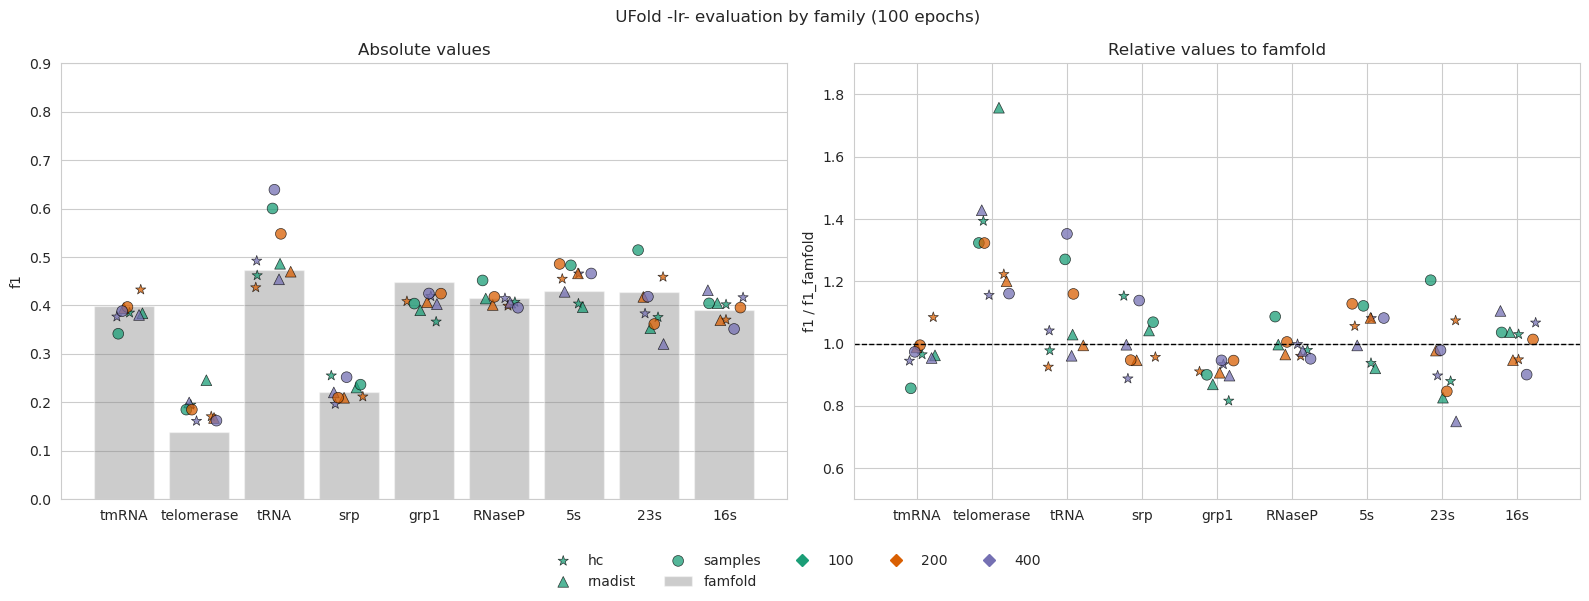

In [21]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Absolute values")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Relative values to famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle(" UFold -lr- evaluation by family (100 epochs)")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [20]:
print(dfl)

           fam       modelo        f1   metodo umbral
0        tmRNA       hc_100  0.384994       hc    100
1   telomerase       hc_100  0.194782       hc    100
2         tRNA       hc_100  0.461996       hc    100
3          srp       hc_100  0.255179       hc    100
4         grp1       hc_100  0.366439       hc    100
..         ...          ...       ...      ...    ...
76        grp1  samples_400  0.424699  samples    400
77      RNaseP  samples_400  0.395321  samples    400
78          5s  samples_400  0.466020  samples    400
79         23s  samples_400  0.418123  samples    400
80         16s  samples_400  0.351490  samples    400

[81 rows x 5 columns]
